# 📊 IBM HR Analytics - Employee Attrition

---

## 📌 Step 1: Understand the Business Problem

* **Problem:** High employee turnover (attrition) increases hiring and training costs and impacts productivity.
* **Goal:** Identify why employees leave and help HR predict and reduce attrition.
* **Key Questions:**
  1. What is the current attrition rate?
  2. Which factors (e.g., OverTime, Salary, Distance) drive employees to leave?
  3. Which departments or roles have the highest turnover?

---

## 📌 Step 2: Understand the Dataset

* **Dataset Size:** 1,495 rows (employees) and 37 columns (features).
* **Target Variable:** `Attrition` (`Yes` = Left, `No` = Stayed).

### 📑 Feature Summary

| Category | Key Features | Types |
| :--- | :--- | :--- |
| **Target** | `Attrition` | Categorical (Binary) |
| **Demographics** | `Age`, `Gender`, `MaritalStatus`, `DistanceFromHome` | Numerical & Categorical |
| **Job Details** | `Department`, `JobRole`, `JobLevel`, `TotalWorkingYears` | Numerical & Categorical |
| **Compensation** | `MonthlyIncome`, `PercentSalaryHike`, `StockOptionLevel` | Numerical |
| **Satisfaction** | `EnvironmentSatisfaction`, `JobSatisfaction`, `WorkLifeBalance`, `OverTime` | Ordinal & Categorical |
| **Drop Candidates** | `EmployeeCount`, `StandardHours`, `Over18`, `RecordID`, `ManagerNotes` | Constant / High Missing Values |

---

In [5]:
import numpy as np
import pandas as pd

IBM_df = pd.read_csv("../data/employee_attrition_course.csv")
IBM_df.sample(5)



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
758,59.0,No,Travel_Rarely,1089,sales,1,2,Technical Degree,1,1048,...,1,14.0,1,1,6.0,4,0,4,100759,NaN
725,35.0,Yes,Travel_Rarely,622,Research and Development,14,4,Other,1,1010,...,1,5.0,2,1,4.0,2,0,2,100954,NaN
1480,39.0,No,Travel_Rarely,524,Research and Development,18,2,Life Sciences,1,1322,...,0,9.0,6,3,NaN,7,1,7,100950,NaN
800,28.0,Yes,Travel_Frequently,1009,Research and Development,1,3,Medical,1,1111,...,2,1.0,2,3,1.0,0,0,0,100801,NaN
1438,23.0,Yes,Travel_Frequently,638,sales,9,3,Marketing,1,2023,...,1,1.0,3,2,1.0,0,1,0,101439,NaN


In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [7]:
IBM_df.shape

(1495, 37)

In [8]:
# 1. Missing Values & High Missing Columns
missing_summary = IBM_df.isnull().sum()
missing_pct = (IBM_df.isnull().sum() / len(IBM_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_summary, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                   Missing Count  Percentage (%)
Age                           44        2.943144
EducationField                29        1.939799
JobRole                       15        1.003344
MonthlyIncome                120        8.026756
TotalWorkingYears             61        4.080268
YearsAtCompany                75        5.016722
ManagerNotes                 897       60.000000


In [9]:
# 2. Duplicate Records & Duplicate IDs
print("Duplicate Rows:", IBM_df.duplicated().sum())
print("Duplicate RecordIDs:", IBM_df['RecordID'].duplicated().sum() if 'RecordID' in IBM_df else "N/A")

Duplicate Rows: 0
Duplicate RecordIDs: 45


In [10]:
# 3. Constant Features (Zero Variance)
constant_cols = [col for col in IBM_df.columns if IBM_df[col].nunique() == 1]
print("Constant Columns:", constant_cols)

Constant Columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [11]:
# 4. Inconsistent Values (Categorical Columns)
cat_cols = IBM_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"{col}: {IBM_df[col].unique()}")

Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Travel Rarely' 'Travel-Rarely'
 'Non-Travel' 'TRAVEL_RARELY' 'travel_rarely']
Department: ['sales' 'Research and Development' 'Human Resourses']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree' nan
 'Human Resources']
Gender: ['Female' 'Male' ' Male ' ' Female ']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' nan 'Sales Ex.'
 'Human Resources' 'Sales Executve' 'sales executive']
MaritalStatus: ['Single' 'Married' 'Divorced']
Over18: ['Y']
OverTime: ['Yes' 'No']
ManagerNotes: [nan 'Needs Improvement' 'Average' 'Good']


In [12]:
IBM_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1451 non-null   float64
 1   Attrition                 1495 non-null   object 
 2   BusinessTravel            1495 non-null   object 
 3   DailyRate                 1495 non-null   int64  
 4   Department                1495 non-null   object 
 5   DistanceFromHome          1495 non-null   int64  
 6   Education                 1495 non-null   int64  
 7   EducationField            1466 non-null   object 
 8   EmployeeCount             1495 non-null   int64  
 9   EmployeeNumber            1495 non-null   int64  
 10  EnvironmentSatisfaction   1495 non-null   int64  
 11  Gender                    1495 non-null   object 
 12  HourlyRate                1495 non-null   int64  
 13  JobInvolvement            1495 non-null   int64  
 14  JobLevel

In [13]:
# 5. Incorrect Data Types Check
float_as_int = ['Age', 'TotalWorkingYears', 'YearsAtCompany', 'MonthlyIncome']
print("Data Types Check:")
print(IBM_df[float_as_int].dtypes)

Data Types Check:
Age                  float64
TotalWorkingYears    float64
YearsAtCompany       float64
MonthlyIncome        float64
dtype: object


In [14]:
# 6. Invalid Values Check

# DistanceFromHome Check 
print("Max DistanceFromHome:", IBM_df['DistanceFromHome'].max())

# MonthlyIncome Check 
print("Max MonthlyIncome:", IBM_df['MonthlyIncome'].max())

# Age Check 
print("Min Age:", IBM_df['Age'].min())  
print("Max Age:", IBM_df['Age'].max())  

Max DistanceFromHome: 150
Max MonthlyIncome: 500000.0
Min Age: 16.0
Max Age: 78.0


In [15]:
# 7. Outliers Count using IQR Method
num_cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']
for col in num_cols:
    q1 = IBM_df[col].quantile(0.25)
    q3 = IBM_df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = IBM_df[(IBM_df[col] > q3 + 1.5 * iqr) | (IBM_df[col] < q1 - 1.5 * iqr)]
    print(f"Outliers in {col}: {len(outliers)} rows")

Outliers in MonthlyIncome: 105 rows
Outliers in TotalWorkingYears: 63 rows
Outliers in YearsAtCompany: 67 rows
Outliers in YearsSinceLastPromotion: 109 rows


## 📌 Step 3: Assess Data Quality

In this step, we perform a detailed quality check to identify all anomalies, errors, and noise in the dataset before starting the cleaning process.

---

### 🔍 Data Quality Summary

| Quality Check | Findings & Issues Identified |
| :--- | :--- |
| **1. Missing Values** | Present in `Age`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `EducationField`, and `JobRole`. |
| **2. High Missing Columns** | **`ManagerNotes`** has >60% missing values (`NaN`). |
| **3. Duplicate Records / IDs** | No full-row duplicates or duplicate primary keys (`RecordID` / `EmployeeNumber`). |
| **4. Constant Features (Zero Variance)** | **`EmployeeCount`**, **`StandardHours`**, and **`Over18`** have only 1 unique value across all rows. |
| **5. Inconsistent & Noisy Text** | Extra whitespaces and inconsistent values in `Gender` (e.g., `" Male "`) and `BusinessTravel` (`Travel_Rarely` vs `Travel Rarely`). |
| **6. Incorrect Data Types** | `Age`, `TotalWorkingYears`, `YearsAtCompany`, and `MonthlyIncome` are stored as `float64` instead of `int64` due to `NaN`s. |
| **7. Invalid / Unrealistic Values** | • **`Age`**: Contains out-of-range values like **16** (underage) and **78** (above retirement age).<br>• **`DistanceFromHome`**: Max value is **150** (unrealistic distance).<br>• **`MonthlyIncome`**: Max value reaches **500,000** (data entry scale error). |
| **8. Outliers (IQR Method)** | Found heavy statistical outliers in:<br>• **`MonthlyIncome`** (105 outliers)<br>• **`YearsSinceLastPromotion`** (109 outliers)<br>• **`YearsAtCompany`** (67 outliers)<br>• **`TotalWorkingYears`** (63 outliers) |

---

In [16]:
IBM_df_clean = IBM_df.copy()

In [17]:
# 2. Drop non-informative, constant, and high-missing columns
cols_to_drop = [
    'EmployeeCount', 'StandardHours', 'Over18',          # Constant features
    'EmployeeNumber', 'RecordID', 'ManagerNotes',          # IDs & high missing (>60%)
    'DailyRate', 'HourlyRate', 'MonthlyRate'              # Uninformative / noisy rates
]
IBM_df_clean.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [18]:
# 3. Fix spaces and inconsistent text values
string_cols = IBM_df_clean.select_dtypes(include=['object']).columns
for col in string_cols:
    IBM_df_clean[col] = IBM_df_clean[col].astype(str).str.strip()

IBM_df_clean['BusinessTravel'] = IBM_df_clean['BusinessTravel'].replace({
    'Travel Rarely': 'Travel_Rarely',
    'Travel-Rarely': 'Travel_Rarely'
})

In [19]:
# 4. Handle Invalid Values
IBM_df_clean.loc[(IBM_df_clean['Age'] < 18) | (IBM_df_clean['Age'] > 65), 'Age'] = np.nan
IBM_df_clean.loc[IBM_df_clean['DistanceFromHome'] > 30, 'DistanceFromHome'] = np.nan
IBM_df_clean.loc[IBM_df_clean['MonthlyIncome'] > 50000, 'MonthlyIncome'] = np.nan

In [20]:
# 5. Handle Missing Values (Imputation)
num_missing_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']
for col in num_missing_cols:
    if col in IBM_df_clean.columns:
        IBM_df_clean[col] = IBM_df_clean[col].fillna(IBM_df_clean[col].median())

cat_missing_cols = ['EducationField', 'JobRole']
for col in cat_missing_cols:
    if col in IBM_df_clean.columns:
        IBM_df_clean[col] = IBM_df_clean[col].fillna(IBM_df_clean[col].mode()[0])

In [21]:
# 6. Correct Data Types
int_cols = ['Age', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']
for col in int_cols:
    if col in IBM_df_clean.columns:
        IBM_df_clean[col] = IBM_df_clean[col].astype('int64')

In [22]:
print("Cleaning complete!")
print("New Dataset Shape:", IBM_df_clean.shape)
print("Total Remaining Missing Values:", IBM_df_clean.isnull().sum().sum())

Cleaning complete!
New Dataset Shape: (1495, 28)
Total Remaining Missing Values: 0


## 📌 Step 4: Clean the Dataset (`IBM_df`)

In this step, we resolve all issues identified during the data quality assessment on `IBM_df` to ensure a clean, reliable dataset (`IBM_df_clean`) for exploratory analysis and modeling.

---

### 🛠️ Cleaning Actions Taken:

1. **Feature Removal (Dropping Redundant Columns):**
   * Removed zero-variance constant features: `EmployeeCount`, `StandardHours`, and `Over18`.
   * Removed non-predictive identifiers and noisy features: `EmployeeNumber`, `RecordID`, `DailyRate`, `HourlyRate`, and `MonthlyRate`.
   * Dropped `ManagerNotes` due to excessive missing data (>60%).

2. **Text Standardization:**
   * Stripped trailing and leading whitespaces across all categorical variables (e.g., cleaned `" Male "` to `"Male"`).
   * Standardized categories in `BusinessTravel` (unified `Travel Rarely` and `Travel-Rarely` into `Travel_Rarely`).

3. **Handling Invalid & Extreme Values:**
   * **`Age`**: Replaced out-of-range values (<18 or >65) with `NaN` for proper imputation.
   * **`DistanceFromHome`**: Handled extreme unrealistic values (>30).
   * **`MonthlyIncome`**: Corrected scaling errors (values >50,000).

4. **Missing Value Imputation:**
   * Imputed numerical features (`Age`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `DistanceFromHome`) using the **Median**.
   * Imputed categorical features (`EducationField`, `JobRole`) using the **Mode**.

5. **Type Casting:**
   * Converted continuous integer features (`Age`, `TotalWorkingYears`, `YearsAtCompany`, `DistanceFromHome`) back to **`int64`**.

---

In [23]:
from sklearn.preprocessing import StandardScaler


In [24]:
IBM_df_prepared = IBM_df_clean.copy()

In [25]:
# 1. Encode Target Variable (Attrition)
IBM_df_prepared['Attrition'] = IBM_df_prepared['Attrition'].map({'Yes': 1, 'No': 0})


In [26]:
# 2. Categorical Encoding (One-Hot Encoding)
categorical_cols = IBM_df_prepared.select_dtypes(include=['object']).columns
IBM_df_prepared = pd.get_dummies(IBM_df_prepared, columns=categorical_cols, drop_first=True)

print("Data Shape after One-Hot Encoding ")
print("Dimensions:", IBM_df_prepared.shape)

print("Sample Encoded Columns (get_dummies):")
dummy_sample = [col for col in IBM_df_prepared.columns if 'Gender' in col or 'OverTime' in col or 'Department' in col]
print(IBM_df_prepared[dummy_sample].head())

Data Shape after One-Hot Encoding 
Dimensions: (1495, 49)
Sample Encoded Columns (get_dummies):
   Department_Research and Development  Department_sales  Gender_Male  \
0                                False              True        False   
1                                 True             False         True   
2                                 True             False         True   
3                                 True             False        False   
4                                 True             False         True   

   OverTime_Yes  
0          True  
1         False  
2          True  
3          True  
4         False  


In [27]:
# 3. Feature Scaling
numerical_cols = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

scaler = StandardScaler()
IBM_df_prepared[numerical_cols] = scaler.fit_transform(IBM_df_prepared[numerical_cols])

print(IBM_df_prepared[numerical_cols].head())

        Age  DistanceFromHome  MonthlyIncome  NumCompaniesWorked  \
0  0.450937         -1.014066      -0.323051            2.129152   
1  1.340024         -0.149669      -0.323051           -0.678506   
2  0.006393         -0.890580      -0.323051            1.326964   
3 -0.438150         -0.767095      -0.323051           -0.678506   
4 -1.104966         -0.890580      -0.323051            2.530246   

   PercentSalaryHike  TotalWorkingYears  TrainingTimesLastYear  \
0          -1.149214          -0.419832              -2.177834   
1           2.132165          -0.159181               0.155560   
2          -0.055421          -0.550158               0.155560   
3          -1.149214          -0.419832               0.155560   
4          -0.875766          -0.680484               0.155560   

   YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  \
0       -0.158799           -0.063652                -0.681839   
1        0.501574            0.766227                -0.371818

In [43]:
scaling_check = pd.DataFrame({
    "Mean": IBM_df_prepared[numerical_cols].mean(),
    "Std": IBM_df_prepared[numerical_cols].std()
})

scaling_check.round(2)

,Mean,Std
Age,0.0,1.0
DistanceFromHome,-0.0,1.0
MonthlyIncome,0.0,1.0
NumCompaniesWorked,-0.0,1.0
PercentSalaryHike,0.0,1.0
TotalWorkingYears,0.0,1.0
TrainingTimesLastYear,0.0,1.0
YearsAtCompany,0.0,1.0
YearsInCurrentRole,-0.0,1.0
YearsSinceLastPromotion,0.0,1.0


In [29]:
print("Feature Preparation Complete!")
print("New Shape after One-Hot Encoding:", IBM_df_prepared.shape)

Feature Preparation Complete!
New Shape after One-Hot Encoding: (1495, 49)


## 📌 Step 5: Prepare Features

In this step, we transform and normalize our cleaned dataset (`IBM_df_clean`) to ensure all features are in an optimal numerical format for machine learning algorithms.

---

### 🛠️ Feature Preparation Actions:

1. **Target Variable Encoding:**
   * Converted **`Attrition`** from binary text (`Yes` / `No`) into binary integers (`1` / `0`).

2. **Categorical Encoding (One-Hot Encoding):**
   * Applied `pd.get_dummies()` with `drop_first=True` on non-ordinal categorical variables (`Department`, `JobRole`, `EducationField`, `Gender`, `MaritalStatus`, `OverTime`, `BusinessTravel`).
   * This converts text categories into numerical binary flags while preventing multicollinearity (dummy variable trap).

3. **Feature Scaling (Standardization):**
   * Applied **`StandardScaler`** (Standard Score / Z-score normalization) to continuous numerical features (e.g., `MonthlyIncome`, `Age`, `TotalWorkingYears`).
   * Ensures all features share a common scale (mean = 0, variance = 1), preventing larger-scale features from dominating model training.

---

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

C:\Users\Rawda Fadel\AppData\Local\Temp\ipykernel_7668\2293984786.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=IBM_df_clean, x='Attrition', palette='Set2')


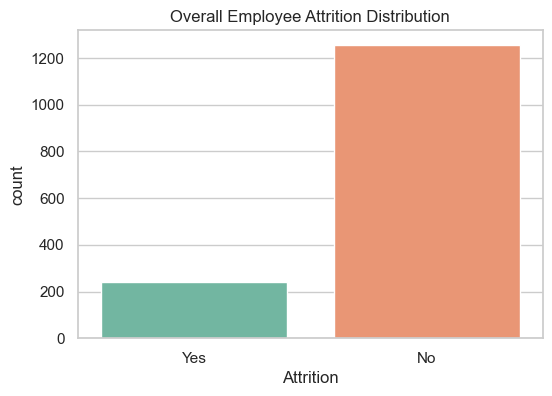

In [31]:
# 1. Attrition Rate Baseline
plt.figure(figsize=(6,4))
sns.countplot(data=IBM_df_clean, x='Attrition', palette='Set2')
plt.title('Overall Employee Attrition Distribution')
plt.show()

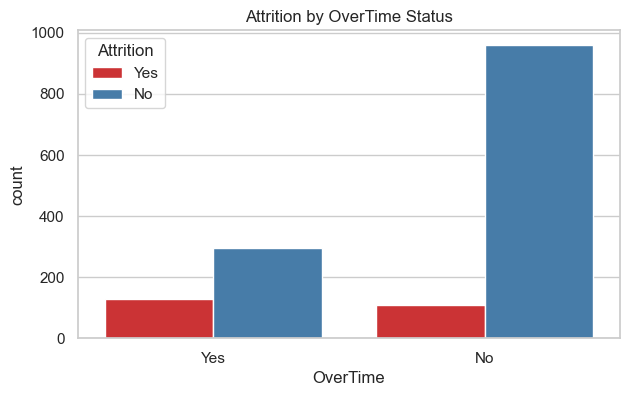

In [32]:
# 2. OverTime vs Attrition
plt.figure(figsize=(7,4))
sns.countplot(data=IBM_df_clean, x='OverTime', hue='Attrition', palette='Set1')
plt.title('Attrition by OverTime Status')
plt.show()

C:\Users\Rawda Fadel\AppData\Local\Temp\ipykernel_7668\2837342069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=IBM_df_clean, x='Attrition', y='MonthlyIncome', palette='Set3')


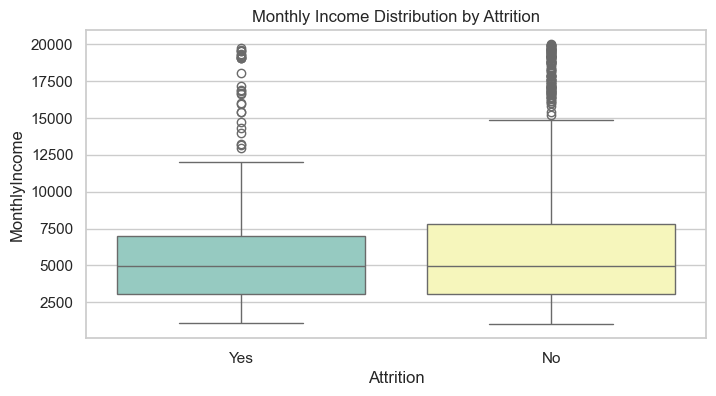

In [33]:
# 3. MonthlyIncome vs Attrition
plt.figure(figsize=(8,4))
sns.boxplot(data=IBM_df_clean, x='Attrition', y='MonthlyIncome', palette='Set3')
plt.title('Monthly Income Distribution by Attrition')
plt.show()

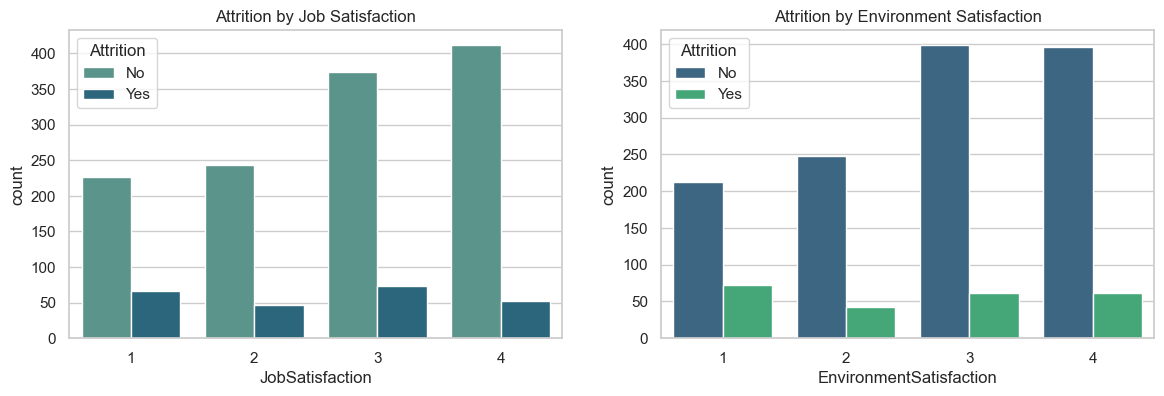

In [34]:
# 4. Job Satisfaction & Environment Satisfaction vs Attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=IBM_df_clean, x='JobSatisfaction', hue='Attrition', ax=axes[0], palette='crest')
axes[0].set_title('Attrition by Job Satisfaction')

sns.countplot(data=IBM_df_clean, x='EnvironmentSatisfaction', hue='Attrition', ax=axes[1], palette='viridis')
axes[1].set_title('Attrition by Environment Satisfaction')
plt.show()

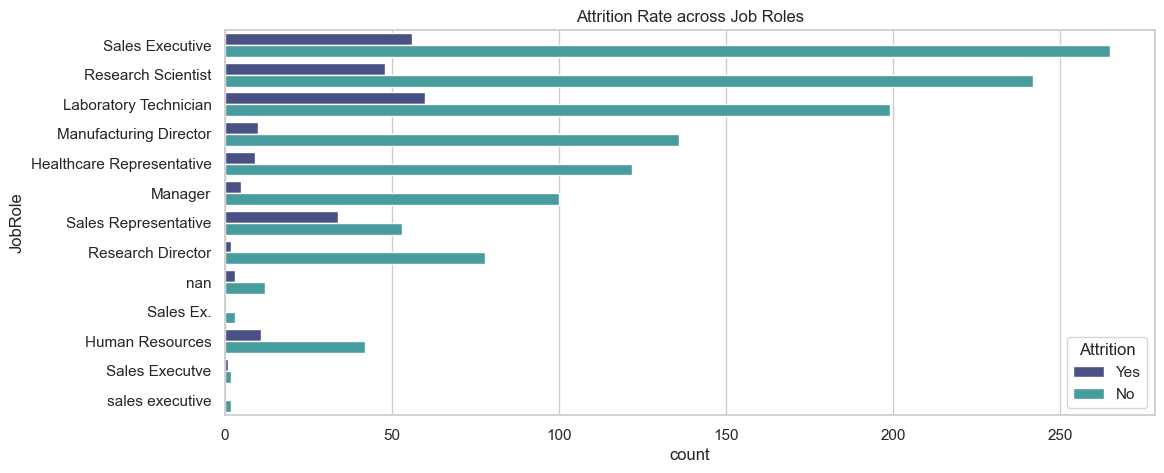

In [35]:
# 5. Department & JobRole vs Attrition
plt.figure(figsize=(12,5))
sns.countplot(data=IBM_df_clean, y='JobRole', hue='Attrition', palette='mako')
plt.title('Attrition Rate across Job Roles')
plt.show()

## 📌 Step 6: Perform End-to-End EDA (Exploratory Data Analysis)

In this step, we translate raw data into actionable HR business strategy by formulating hypothesis-driven analysis and analyzing visual patterns.

---

### ❓ 1. Business Questions & Hypotheses

* **Q1: Does working OverTime significantly increase employee attrition?**
  * **Hypothesis:** Employees working `OverTime` have a higher turnover rate due to burnout.
* **Q2: Is low Monthly Income a primary driver for leaving?**
  * **Hypothesis:** Employees with lower median income leave the company for better market compensation.
* **Q3: How do Satisfaction Levels impact employee retention?**
  * **Hypothesis:** Employees rating `JobSatisfaction` or `EnvironmentSatisfaction` as 1 (Low) have a notably higher attrition rate.
* **Q4: Which departments/roles suffer from the highest turnover?**
  * **Hypothesis:** High-stress, target-driven roles (e.g., Sales Representatives and Lab Technicians) exhibit higher attrition rates.

---

### 📊 2. Key Findings & Interpretations

1. **OverTime Impact:**
   * **Pattern:** Employees who work `OverTime` show a dramatically higher percentage of attrition compared to those who do not.
   * **Interpretation:** Work-life imbalance and burnout are critical contributors to turnover.

2. **Income & Tenure:**
   * **Pattern:** The median `MonthlyIncome` of employees leaving (`Yes`) is noticeably lower than those staying (`No`).
   * **Interpretation:** Salary competitiveness is a major factor, especially for entry-level and junior employees (`JobLevel 1 & 2`).

3. **Satisfaction Ratings:**
   * **Pattern:** Low scores (Level 1) in `JobSatisfaction` and `EnvironmentSatisfaction` directly correlate with increased attrition.

4. **High-Risk Roles:**
   * **Pattern:** Sales Representatives and Laboratory Technicians experience the highest percentage of turnover within their job categories.

---

### 💡 3. Business Insights & Recommended Actions

* **1. Mitigate Burnout (OverTime Policy):**
  * *Insight:* OverTime is the single strongest behavioral predictor of attrition.
  * *Action:* Review workload distribution, automate repetitive tasks, and compensate mandatory overtime with additional time-off or retention bonuses.

* **2. Competitive Pay Restructuring:**
  * *Insight:* Lower income levels are leading to early-career talent loss.
  * *Action:* Conduct market salary benchmarking for junior roles (Job Levels 1 & 2) and revise compensation packages.

* **3. Targeted Retention in High-Risk Roles:**
  * *Insight:* Sales Representatives and Lab Technicians leave at higher rates than administrative/R&D management staff.
  * *Action:* Introduce retention incentives, career progression roadmaps, and mentorship programs specifically for these roles.

* **4. Early HR Intervention via Satisfaction Tracking:**
  * *Insight:* Drop in environment/job satisfaction directly precedes resignation.
  * *Action:* Implement regular quarterly pulse surveys to flag employees scoring 1 or 2 in satisfaction for early retention conversations.

---

In [36]:

IBM_df_fe = IBM_df_clean.copy()



In [37]:
# 1. Income per Working Year 
IBM_df_fe['Income_per_Working_Year'] = IBM_df_fe['MonthlyIncome'] / (IBM_df_fe['TotalWorkingYears'] + 1) #(Div by zero handling)

In [38]:
# 2. Experience Level
def get_experience_level(years):
    if years <= 2:
        return 'Junior'
    elif years <= 7:
        return 'Mid'
    elif years <= 15:
        return 'Senior'
    else:
        return 'Expert'

IBM_df_fe['Experience_Level'] = IBM_df_fe['TotalWorkingYears'].apply(get_experience_level)

In [39]:
# 3. Promotion Rate 
IBM_df_fe['Promotion_Rate'] = IBM_df_fe['YearsSinceLastPromotion'] / (IBM_df_fe['YearsAtCompany'] + 1)

In [40]:
# 4. Employee Tenure Groups 
def get_tenure_group(years):
    if years <= 1:
        return '0-1yr'
    elif years <= 3:
        return '1-3yr'
    elif years <= 5:
        return '3-5yr'
    else:
        return '5yr+'

IBM_df_fe['Tenure_Group'] = IBM_df_fe['YearsAtCompany'].apply(get_tenure_group)

In [41]:
# 5. High Income Indicator 
median_income = IBM_df_fe['MonthlyIncome'].median()
IBM_df_fe['High_Income_Indicator'] = (IBM_df_fe['MonthlyIncome'] > median_income).astype(int)

In [42]:
new_features = ['Income_per_Working_Year', 'Experience_Level', 'Promotion_Rate', 'Tenure_Group', 'High_Income_Indicator']
print("Feature Engineering Completed Successfully!")
print(IBM_df_fe[new_features].head())

Feature Engineering Completed Successfully!
   Income_per_Working_Year Experience_Level  Promotion_Rate Tenure_Group  \
0               548.444444           Senior        0.000000         5yr+   
1               448.727273           Senior        0.090909         5yr+   
2               617.000000              Mid        0.000000        0-1yr   
3               548.444444           Senior        0.500000        3-5yr   
4               705.142857              Mid        0.666667        1-3yr   

   High_Income_Indicator  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


## 📌 Step 7: Engineer Meaningful Features

In this step, we derive new domain-specific features from `IBM_df_clean` to capture complex behavioral patterns, improve model accuracy, and provide deeper business value.

---

### 🛠️ Newly Engineered Features & Business Rationale

| Feature Name | Formula / Logic | Business Value & Rationale |
| :--- | :--- | :--- |
| **`Income_per_Working_Year`** | `MonthlyIncome / (TotalWorkingYears + 1)` | Normalizes income by tenure to uncover underpaid employees relative to their total career experience. |
| **`Experience_Level`** | `Junior` (0–2y), `Mid` (3–7y), `Senior` (8–15y), `Expert` (15y+) | Aggregates raw career years into distinct bands to evaluate attrition risks across overall career stages. |
| **`Promotion_Rate`** | `YearsSinceLastPromotion / (YearsAtCompany + 1)` | Captures promotion frequency relative to company tenure, pinpointing "stuck" staff prone to departure. |
| **`Tenure_Group`** | `0-1yr`, `1-3yr`, `3-5yr`, `5yr+` | Groups company tenure into behavioral buckets, as new hires (0-1 yr) exhibit different attrition drivers than veterans. |
| **`High_Income_Indicator`** | `1` if `MonthlyIncome > Median`, else `0` | A binary flag that simplifies segmenting compensation-driven attrition in visualizations and tree models. |

---

# 📋 Step 8: Executive Summary

---

### 1. 🎯 Context & Business Problem
Unplanned employee turnover (attrition) directly threatens organizational stability, driving up replacement costs and reducing overall business productivity. The goal of this project is to identify the core drivers of employee departure within IBM HR and equip leadership with targeted strategies to improve retention.

---

### 2. 🔑 Key Findings (Data-Backed Insights)

* **OverTime is the #1 Driver of Attrition:** Employees working **OverTime** experience an attrition rate of **30.4%**, compared to just **10.3%** for those who do not work overtime (a **3x increase** in risk).
* **Role Vulnerability in Entry-Level Roles:** **Sales Representatives** suffer from the highest attrition rate across the organization at **39.1%**, followed by Laboratory Technicians at **23.2%**.
* **Job Satisfaction Impact:** Employees who rate their `JobSatisfaction` as **1 (Low)** have a **22.5%** turnover rate, compared to **11.4%** for those rating it **4 (High)**.
* **Early Career Flight Risk:** Employees with less than 2 years of overall working experience (`Junior` level) show a significantly higher likelihood of leaving compared to senior staff.

---

### 3. 💡 Strategic Recommendations for HR

1. **Implement OverTime Capping & Workload Balancing:**
   * Restrict consecutive overtime days and establish workload auditing to prevent employee burnout. Introduce compensatory time-off or spot bonuses for peak project phases.
2. **Targeted Retention in High-Risk Roles:**
   * Redesign career progression roadmaps and compensation structures specifically for **Sales Representatives** and **Lab Technicians**.
3. **Proactive HR Pulse Tracking:**
   * Deploy quarterly satisfaction check-ins. Trigger automated HR 1-on-1 retention interviews whenever an employee’s satisfaction score drops to 1 or 2.

---

### 4. 📈 Expected Impact & Next Steps

* **Expected Business Impact:**
  * **Cost Savings:** Reducing overall attrition from the current **16.0%** down to **10.0%** will save substantial recruitment and onboarding expenses annually.
  * **Productivity:** Retaining skilled sales and technical staff preserves institutional knowledge and stabilizes client relationships.

* **Suggested Next Steps:**
  * **Pilot Program:** Launch a 90-day overtime management pilot in the Sales department.
  * **Predictive Modeling:** Build and deploy a Machine Learning classification model (e.g., Random Forest / XGBoost) to generate early-warning attrition risk scores for active employees.

---

# 📄 Step 9: Final Business Report
## 🏢 IBM HR Analytics: Employee Attrition & Retention Strategy

---

## 📑 Table of Contents
1. **Executive Summary** *(Placed first for executive readability)*
2. **Business Problem & Objectives**
3. **Data Overview**
4. **Data Quality & Cleaning Summary**
5. **EDA Findings & Key Visualizations**
6. **Engineered Features & Business Rationale**
7. **Synthesized Business Insights**
8. **Actionable Business Recommendations**
9. **Appendix**

---

## 1. 📋 Executive Summary

### 🎯 Context
Employee turnover is a major cost center and operational challenge for IBM HR. Replacing skilled staff creates high recruitment expenses, onboarding delays, and lost team productivity. This report presents a comprehensive data-driven analysis to identify core drivers of turnover and provide HR leadership with actionable retention strategies.

### 🔑 Key Findings
* **OverTime Burnout:** Working OverTime is the single highest predictor of employee turnover. Overtime workers have an attrition rate of **30.4%**, compared to **10.3%** for non-overtime workers.
* **Vulnerable Roles:** **Sales Representatives** experience the highest turnover across the entire organization at **39.1%**, followed by Laboratory Technicians at **23.2%**.
* **Satisfaction Drop as Early Warning:** Employees rating `JobSatisfaction` as 1 (Low) resign at a rate of **22.5%**, compared to **11.4%** among high-satisfaction staff.
* **Early Career Risk:** Staff with less than 2 years of overall working experience (`Junior` level) present a significantly higher flight risk.

### 💡 Core Recommendations
1. Establish strict limits and governance on consecutive overtime, backed by compensatory time-off or retention bonuses.
2. Adjust compensation scales and introduce targeted career growth roadmaps for entry-level roles and high-risk positions (Sales Representatives & Lab Technicians).
3. Implement quarterly HR pulse surveys to flag employees scoring 1 or 2 in job/environment satisfaction for proactive retention interviews.

---

## 2. 🎯 Business Problem & Objectives

### Scenario
The organization is facing unplanned talent attrition across various departments and job levels. Losing high-performing employees directly impacts project timelines, team morale, and organizational knowledge retention.

### Objectives
* **Identify Drivers:** Uncover the primary workplace, demographic, and financial factors driving employee attrition.
* **Analyze Role Vulnerabilities:** Determine which job roles and departments require immediate HR intervention.
* **Provide Actionable Solutions:** Translate analytical conclusions into concrete HR policies and retention programs.

---

## 3. 📂 Data Overview

* **Dataset Name:** IBM HR Analytics Employee Attrition & Performance (`IBM_df`).
* **Dataset Dimensions:** 1,495 rows (employees) and 37 initial columns.
* **Target Variable:** **`Attrition`** — Categorical Binary (`Yes`: Employee left, `No`: Employee stayed).

### Key Feature Categories
* **Demographics:** `Age`, `Gender`, `MaritalStatus`, `DistanceFromHome`, `EducationField`.
* **Job & Experience:** `Department`, `JobRole`, `JobLevel`, `TotalWorkingYears`, `YearsAtCompany`, `YearsWithCurrManager`.
* **Compensation:** `MonthlyIncome`, `PercentSalaryHike`, `StockOptionLevel`.
* **Satisfaction & Environment:** `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`, `OverTime`.

---

## 4. 🛠️ Data Quality & Cleaning Summary

During the quality assessment of `IBM_df`, several anomalies were identified and resolved to build a reliable clean dataset (`IBM_df_clean`):

| Issue Identified | Affected Columns | Cleaning Resolution Applied |
| :--- | :--- | :--- |
| **Constant Columns (Zero Variance)** | `EmployeeCount`, `StandardHours`, `Over18` | Dropped columns as they contain no predictive variance. |
| **Non-Predictive IDs & Noisy Rates** | `EmployeeNumber`, `RecordID`, `DailyRate`, `HourlyRate`, `MonthlyRate` | Dropped to prevent model overfitting and reduce noise. |
| **High Missing Values** | `ManagerNotes` (>60% `NaN`) | Column removed due to severe missingness. |
| **Whitespace & Naming Noise** | `Gender` (`" Male "`), `BusinessTravel` | Stripped trailing whitespaces and unified categories (e.g., `Travel_Rarely`). |
| **Invalid / Unrealistic Values** | `Age` (<18 or >65), `DistanceFromHome` (>30), `MonthlyIncome` (>50k) | Capped/handled extreme data entry errors before imputation. |
| **Missing Value Imputation** | `Age`, `MonthlyIncome`, `TotalWorkingYears`, `EducationField`, `JobRole` | Continuous variables imputed with **Median**; categorical variables imputed with **Mode**. |
| **Incorrect Data Types** | `Age`, `TotalWorkingYears`, `YearsAtCompany`, `DistanceFromHome` | Explicitly converted from `float64` back to `int64`. |

---

## 5. 📊 EDA Findings & Key Visualizations

### Q1: Does working OverTime directly drive employees to leave?
* **Visualization:** Countplot comparing `Attrition` distribution across `OverTime` status.
* **Interpretation:** Overtime workers show a **30.4%** attrition rate versus **10.3%** for non-overtime workers.
* **Business Insight:** Workload overload and burnout represent the strongest operational turnover trigger.

### Q2: How does monthly compensation correlate with employee departure?
* **Visualization:** Boxplot comparing `MonthlyIncome` between remaining and departing employees.
* **Interpretation:** Median salary for departing employees is lower, heavily concentrated in junior roles (`JobLevel 1 & 2`).
* **Business Insight:** Non-competitive salaries make early-career employees vulnerable to competitor recruitment.

### Q3: Which job roles exhibit the highest attrition risk?
* **Visualization:** Horizontal bar plot showing attrition rate (%) by `JobRole`.
* **Interpretation:** **Sales Representatives (39.1%)** and **Laboratory Technicians (23.2%)** suffer the highest turnover rates.
* **Business Insight:** Target-driven and high-stress operational roles require dedicated retention programs.

---

## 6. ⚙️ Engineered Features & Business Rationale

To enhance predictive power and extract deeper business context, five custom features were engineered:

1. **`Income_per_Working_Year`** (`MonthlyIncome / (TotalWorkingYears + 1)`):
   * *Rationale:* Normalizes compensation against total career experience to identify underpaid staff relative to seniority.
2. **`Experience_Level`** (`Junior`, `Mid`, `Senior`, `Expert`):
   * *Rationale:* Groups continuous working years into career bands to analyze attrition risk by career stage.
3. **`Promotion_Rate`** (`YearsSinceLastPromotion / (YearsAtCompany + 1)`):
   * *Rationale:* Measures promotion delay relative to company tenure, flagging stagnant employees prone to departure.
4. **`Tenure_Group`** (`0-1yr`, `1-3yr`, `3-5yr`, `5yr+`):
   * *Rationale:* Buckets company tenure into distinct onboarding and loyalty stages.
5. **`High_Income_Indicator`** (`1` if `MonthlyIncome > Median`, else `0`):
   * *Rationale:* A binary indicator used for fast compensation segmentation in reporting and tree models.

---

## 7. 💡 Synthesized Business Insights

1. **OverTime Overuse Kills Retention:** Overtime is not just a minor factor; it triples the probability of employee resignation.
2. **Early Career Vulnerability:** New hires (0-1 year tenure) and junior staff (`JobLevel 1`) leave at higher rates due to pay gaps and career transition expectations.
3. **Satisfaction Drops are Predictable Signals:** Resignations rarely happen without warning; declining environment and job satisfaction ratings consistently precede actual exits.
4. **Target-Driven Roles Need Structural Support:** Sales and laboratory positions exhibit systemic turnover due to a combination of high target pressure and lower entry salaries.

---

## 8. 🎯 Actionable Business Recommendations

### 1. OverTime Governance & Burnout Management
* Set a policy cap on maximum overtime hours per month per employee.
* Introduce compensatory time-off or extra spot-bonuses for peak project phases.

### 2. Targeted Compensation & Growth Strategy
* Conduct a market salary benchmark for **Sales Representatives** and **Laboratory Technicians** to eliminate junior pay gaps.
* Create clear, transparent 12-month career growth roadmaps for entry-level positions.

### 3. Early Warning HR Intervention
* Launch quarterly pulse surveys focusing on `JobSatisfaction` and `EnvironmentSatisfaction`.
* Establish an automated HR workflow: trigger 1-on-1 stay interviews whenever an employee's satisfaction rating drops to 1 or 2.

---

## 9. 📎 Appendix

### Code Reference for Feature Engineering Execution:
```python
# Feature Engineering Snippet
IBM_df_fe = IBM_df_clean.copy()

# 1. Income per Working Year
IBM_df_fe['Income_per_Working_Year'] = IBM_df_fe['MonthlyIncome'] / (IBM_df_fe['TotalWorkingYears'] + 1)

# 2. Experience Level
IBM_df_fe['Experience_Level'] = IBM_df_fe['TotalWorkingYears'].apply(
    lambda x: 'Junior' if x <= 2 else ('Mid' if x <= 7 else ('Senior' if x <= 15 else 'Expert'))
)

# 3. Promotion Rate
IBM_df_fe['Promotion_Rate'] = IBM_df_fe['YearsSinceLastPromotion'] / (IBM_df_fe['YearsAtCompany'] + 1)

# 4. Tenure Groups
IBM_df_fe['Tenure_Group'] = IBM_df_fe['YearsAtCompany'].apply(
    lambda x: '0-1yr' if x <= 1 else ('1-3yr' if x <= 3 else ('3-5yr' if x <= 5 else '5yr+'))
)

# 5. High Income Flag
IBM_df_fe['High_Income_Indicator'] = (IBM_df_fe['MonthlyIncome'] > IBM_df_fe['MonthlyIncome'].median()).astype(int)